# Photonic Quantum Kernel (Havlíček-inspired)

This notebook implements a photonic analogue of the quantum kernel
introduced in Havlíček et al. (2019).

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

### Part 01: Basic Photonic Kernel

We define a photonic feature map:

U(x) = B * Φ(x) * B

where B is a beam splitter and Φ(x) encodes classical data as phases.

[[1.         0.5        0.62940952]
 [0.5        1.         0.98296291]
 [0.62940952 0.98296291 1.        ]]
Diagonals: [1. 1. 1.]
Symmetric: True


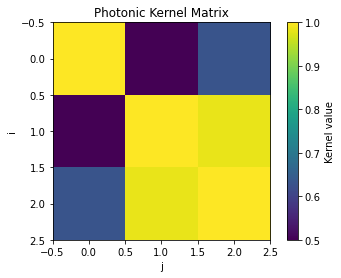

In [6]:
#Beam splitter
B = np.array([[1, 1j],
             [1j, 1]], dtype=complex) /np.sqrt(2)

#phase encoding matrix
def phi(x1, x2):
    return np.array([[np.exp(1j * x1), 0],
                    [0, np.exp(1j * x2)]], dtype=complex)

#Feature-map unitary
def unitary(x1, x2):
    return B @ phi(x1, x2) @ B

#input state |1,0> as a column vector
psi_in = np.array([1, 0], dtype=complex)

#output state |phi(x)>
def state(x):
    x1, x2 = x
    return unitary(x1, x2) @ psi_in
                    
#Kernel value K(x, x')
def photonic_kernel(x, xp):
    psi_x = state(x)
    psi_xp = state(xp)
    overlap = np.vdot(psi_x, psi_xp) #inner product of psi_x and psi_xp
    return np.abs(overlap)**2

#kernel matrix
def photonic_kernel_matrix(X):
    n = len(X)
    K = np.zeros((n, n), dtype=float)
    for i in range(n):
        for j in range(n):
            K[i,j] = photonic_kernel(X[i], X[j])
    return K

# Example data points
X = np.array([
    [np.pi/2, np.pi],
    [0, 0],
    [np.pi/4, np.pi/3]
])

K = photonic_kernel_matrix(X)
print(K)
print("Diagonals:", np.diag(K))
print("Symmetric:", np.allclose(K, K.T))

plt.imshow(K, cmap='viridis')
plt.colorbar(label="Kernel value")
plt.title("Photonic Kernel Matrix")
plt.xlabel("j")
plt.ylabel("i")
plt.show()

### Classification with SVM

We use a precomputed kernel with an SVM classifier to evaluate
the performance of the photonic kernel.

In [7]:
#Sample dataset
X = np.array([
    [0.1, 0.2],
    [0.2, 0.1],
    [0.15, 0.25],
    [0.25, 0.15],
    [1.8, 1.9],
    [1.9, 1.8],
    [1.7, 1.85],
    [1.85, 1.7]
])

y = np.array([0, 0, 0, 0, 1, 1, 1, 1]) #classification -- first 4 classified as 0 and last 4 classified as 1

#Splitting the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

#Kernel matrix between two sets
def kernel_matrix(A, B):
    K = np.zeros((len(A), len(B)))
    for i in range(len(A)):
        for j in range(len(B)):
            K[i,j] = photonic_kernel(A[i], B[j])
    return K

#Build train/test kernel matrices
K_all = photonic_kernel_matrix(X)
print("Photonic Kernel Matrix: \n", K_all)
print("Diagonals:", np.diag(K_all))
print("Symmetric:", np.allclose(K_all, K_all.T))

K_train = kernel_matrix(X_train, X_train)
K_test = kernel_matrix(X_test, X_train)

#Classification
clf = SVC(kernel="precomputed")
clf.fit(K_train, y_train)

#predict
y_pred = clf.predict(K_test)

print("Predictions:", y_pred)
print("True labels", y_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


Photonic Kernel Matrix: 
 [[1.         0.99003329 1.         0.99003329 1.         0.99003329
  0.99937513 0.98445621]
 [0.99003329 1.         0.99003329 1.         0.99003329 1.
  0.98445621 0.99937513]
 [1.         0.99003329 1.         0.99003329 1.         0.99003329
  0.99937513 0.98445621]
 [0.99003329 1.         0.99003329 1.         0.99003329 1.
  0.98445621 0.99937513]
 [1.         0.99003329 1.         0.99003329 1.         0.99003329
  0.99937513 0.98445621]
 [0.99003329 1.         0.99003329 1.         0.99003329 1.
  0.98445621 0.99937513]
 [0.99937513 0.98445621 0.99937513 0.98445621 0.99937513 0.98445621
  1.         0.97766824]
 [0.98445621 0.99937513 0.98445621 0.99937513 0.98445621 0.99937513
  0.97766824 1.        ]]
Diagonals: [1. 1. 1. 1. 1. 1. 1. 1.]
Symmetric: True
Predictions: [0 0]
True labels [0 1]
Accuracy: 0.5


NOTE: The simplest photonic analogue U(x)=BΦ(x)B yields a valid kernel, but it is not expressive enough for nontrivial classification because it collapses inputs with similar relative phase(see below)

In [46]:
print("Here checking how relative phases far apart:")
for x in X:
    print(x, "x1-x2 =", x[0] - x[1])

Here checking how relative phases far apart:
[0.1 0.2] x1-x2 = -0.1
[0.2 0.1] x1-x2 = 0.1
[0.15 0.25] x1-x2 = -0.1
[0.25 0.15] x1-x2 = 0.1
[1.8 1.9] x1-x2 = -0.09999999999999987
[1.9 1.8] x1-x2 = 0.09999999999999987
[1.7  1.85] x1-x2 = -0.15000000000000013
[1.85 1.7 ] x1-x2 = 0.15000000000000013


### Phase Modification

In order to break symmetry in relative phases we modify the phase.

U(x) = B * Φ_2(x) * Φ_1(x) * B

where B is a beam splitter and Φ_1(x), Φ_2(x) encodes classical data as phases.

[[1.         0.5        0.01703709]
 [0.5        1.         0.37059048]
 [0.01703709 0.37059048 1.        ]]
Diagonals: [1. 1. 1.]
Symmetric: True


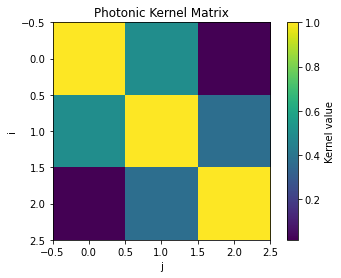

In [8]:
#Phase modification

#Beam splitter
B = np.array([[1, 1j],
             [1j, 1]], dtype=complex) /np.sqrt(2)

#phase encoding matrix- two layers
def phi1(x1, x2):
    return np.array([[np.exp(1j * x1), 0],
                    [0, np.exp(1j * x2)]], dtype=complex)
def phi2(x1, x2):
    return np.array([[np.exp(1j * (x1 + x2)), 0],
                    [0, np.exp(1j * (x1 - x2))]], dtype=complex)

#Feature-map unitary
def unitary(x1, x2):
    return B @ phi2(x1, x2) @  phi1(x1, x2) @ B

#input state |1,0> as a column vector
psi_in = np.array([1, 0], dtype=complex)

#output state |phi(x)>
def state(x):
    x1, x2 = x
    return unitary(x1, x2) @ psi_in
                    
#Kernel value K(x, x')
def photonic_kernel(x, xp):
    psi_x = state(x)
    psi_xp = state(xp)
    overlap = np.vdot(psi_x, psi_xp) #inner product of psi_x and psi_xp
    return np.abs(overlap)**2

#kernel matrix
def photonic_kernel_matrix(X):
    n = len(X)
    K = np.zeros((n, n), dtype=float)
    for i in range(n):
        for j in range(n):
            K[i,j] = photonic_kernel(X[i], X[j])
    return K

# Example data points
X = np.array([
    [np.pi/2, np.pi],
    [0, 0],
    [np.pi/4, np.pi/3]
])

K = photonic_kernel_matrix(X)
print(K)
print("Diagonals:", np.diag(K))
print("Symmetric:", np.allclose(K, K.T))

plt.imshow(K, cmap='viridis')
plt.colorbar(label="Kernel value")
plt.title("Photonic Kernel Matrix")
plt.xlabel("j")
plt.ylabel("i")
plt.show()

NOTE: Kernel matrix looks much more expressive after phase modification.

Let's try to perform classification using our new kernel.

In [9]:
#Sample dataset
X = np.array([
    [0.1, 0.2],
    [0.2, 0.1],
    [0.15, 0.25],
    [0.25, 0.15],
    [1.8, 1.9],
    [1.9, 1.8],
    [1.7, 1.85],
    [1.85, 1.7]
])

y = np.array([0, 0, 0, 0, 1, 1, 1, 1]) #classification -- first 4 classified as 0 and last 4 classified as 1

#Splitting the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

#Kernel matrix between two sets
def kernel_matrix(A, B):
    K = np.zeros((len(A), len(B)))
    for i in range(len(A)):
        for j in range(len(B)):
            K[i,j] = photonic_kernel(A[i], B[j])
    return K

#Build train/test kernel matrices
K_all = photonic_kernel_matrix(X)
print("Photonic Kernel Matrix: \n", K_all)
print("Diagonals:", np.diag(K_all))
print("Symmetric:", np.allclose(K_all, K_all.T))

K_train = kernel_matrix(X_train, X_train)
K_test = kernel_matrix(X_test, X_train)

#Classification
clf_q = SVC(kernel="precomputed")
clf_q.fit(K_train, y_train)

#predict
y_pred = clf_q.predict(K_test)

print("Predictions:", y_pred)
print("True labels", y_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


Photonic Kernel Matrix: 
 [[1.00000000e+00 1.00000000e+00 9.97502083e-01 9.97502083e-01
  1.66009037e-02 1.66009037e-02 2.93516196e-03 2.93516196e-03]
 [1.00000000e+00 1.00000000e+00 9.97502083e-01 9.97502083e-01
  1.66009037e-02 1.66009037e-02 2.93516196e-03 2.93516196e-03]
 [9.97502083e-01 9.97502083e-01 1.00000000e+00 1.00000000e+00
  6.26011505e-03 6.26011505e-03 1.76707643e-05 1.76707643e-05]
 [9.97502083e-01 9.97502083e-01 1.00000000e+00 1.00000000e+00
  6.26011505e-03 6.26011505e-03 1.76707643e-05 1.76707643e-05]
 [1.66009037e-02 1.66009037e-02 6.26011505e-03 6.26011505e-03
  1.00000000e+00 1.00000000e+00 9.94385539e-01 9.94385539e-01]
 [1.66009037e-02 1.66009037e-02 6.26011505e-03 6.26011505e-03
  1.00000000e+00 1.00000000e+00 9.94385539e-01 9.94385539e-01]
 [2.93516196e-03 2.93516196e-03 1.76707643e-05 1.76707643e-05
  9.94385539e-01 9.94385539e-01 1.00000000e+00 1.00000000e+00]
 [2.93516196e-03 2.93516196e-03 1.76707643e-05 1.76707643e-05
  9.94385539e-01 9.94385539e-01 1.000

NOTE: Modified phase kernel succesfuly performed classification on our toy dataset.

### Decision Boundaries and Comparison to Classical RBF method

In [11]:
#Classic kernel 
def classic_rbf_kernel(x1, x2, gamma=1.0):
    return np.exp(-gamma * np.linalg.norm(x1 - x2)**2)

def classical_kernel_matrix(A, B, gamma=1.0):
    K = np.zeros((len(A), len(B)))
    for i in range(len(A)):
        for j in range(len(B)):
            K[i,j] = classic_rbf_kernel(A[i], B[j], gamma=gamma)
    return K

Kc = classical_kernel_matrix(X, X)
print("Quantum kernel martix:\n", K_all)
print("Classical kernel martix:\n", Kc)

Quantum kernel martix:
 [[1.         0.99013262 0.9999751  0.99005818 0.99019875 0.9999915
  0.98454961 0.99930048]
 [0.99013262 1.         0.99025586 0.9999751  0.99948551 0.99019875
  0.99890113 0.98446893]
 [0.9999751  0.99025586 1.         0.99013262 0.99009568 0.99999569
  0.98446893 0.99915849]
 [0.99005818 0.9999751  0.99013262 1.         0.99968334 0.99009568
  0.99912746 0.98446266]
 [0.99019875 0.99948551 0.99009568 0.99968334 1.         0.99013262
  0.99933786 0.98504505]
 [0.9999915  0.99019875 0.99999569 0.99009568 0.99013262 1.
  0.98449348 0.99922644]
 [0.98454961 0.99890113 0.98446893 0.99912746 0.99933786 0.98449348
  1.         0.97816695]
 [0.99930048 0.98446893 0.99915849 0.98446266 0.98504505 0.99922644
  0.97816695 1.        ]]
Classical kernel martix:
 [[1.         0.98019867 0.99501248 0.97530991 0.00308872 0.00302755
  0.00507972 0.00492959]
 [0.98019867 1.         0.97530991 0.99501248 0.00302755 0.00308872
  0.00492959 0.00507972]
 [0.99501248 0.97530991 1.  

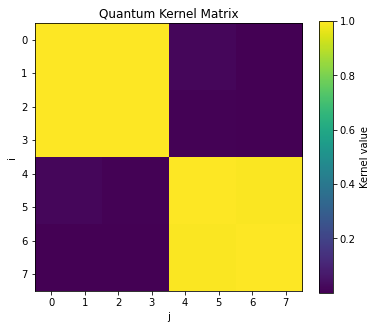

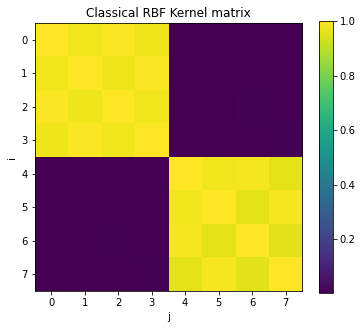

Quantum kernel matrix diagonal: [1. 1. 1. 1. 1. 1. 1. 1.]
Symmetry: True
Classical kernel matrix diagonal: [1. 1. 1. 1. 1. 1. 1. 1.]
Symmetry: True


In [38]:
#Visual comparison
plt.figure(figsize=(6,5))
plt.imshow(K_all)
plt.colorbar(label="Kernel value")
plt.title("Quantum Kernel Matrix")
plt.xlabel("j")
plt.ylabel("i")
plt.show

plt.figure(figsize=(6,5))
plt.imshow(Kc)
plt.colorbar()
plt.title("Classical RBF Kernel matrix")
plt.xlabel("j")
plt.ylabel("i")
plt.show()

print("Quantum kernel matrix diagonal:", np.diag(K_all))
print("Symmetry:", np.allclose(K_all, K_all.T))

print("Classical kernel matrix diagonal:", np.diag(Kc))
print("Symmetry:", np.allclose(Kc, Kc.T))

NOTE: Photonic kernel matrix looks much more flat compared to classical kernel, which is surprizing because Havlicek style kernel was direct opposite.

In [41]:
#Training SVM with classical kernel
Kc_train = classical_kernel_matrix(X_train, X_train, gamma=1.0)
Kc_test = classical_kernel_matrix(X_test, X_train, gamma=1.0)

clf_c = SVC(kernel="precomputed")
clf_c.fit(Kc_train, y_train)
y_pred_c = clf_c.predict(Kc_test)

print("Classical prediction:", y_pred_c)
print("Classical accuracy:", accuracy_score(y_test, y_pred_c))

Classical prediction: [0 1]
Classical accuracy: 1.0


### Decision Boundary Visualization

We evaluate how well the kernel separates classes in input space.

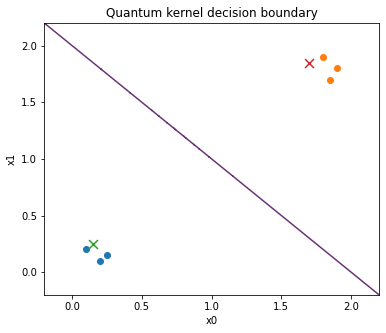

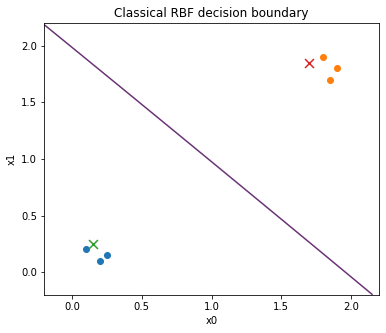

In [42]:
#Quantum desicion boundary

#Creating a grid in input space
x0_min, x0_max = X[:, 0].min() - 0.3, X[:, 0].max() + 0.3
x1_min, x1_max = X[:, 1].min() - 0.3, X[:, 1].max() + 0.3

xx, yy = np.meshgrid(
    np.linspace(x0_min, x0_max, 200),
    np.linspace(x1_min, x1_max, 200)
)
grid_points = np.c_[xx.ravel(), yy.ravel()]

#Quantum kernel between grid points and training points
K_grid_q = kernel_matrix(grid_points, X_train)

#Predict class of each point
Z_q = clf_q.decision_function(K_grid_q)
Z_q = Z_q.reshape(xx.shape)

#Plot
plt.figure(figsize=(6,5))
plt.contour(xx, yy, Z_q, levels=[0], alpha=0.8)

for label in np.unique(y_train):
    pts = X_train[y_train == label]
    plt.scatter(pts[:,0], pts[:,1], label=f"train class{label}")
    
for label in np.unique(y_test):
    pts = X_test[y_test == label]
    plt.scatter(pts[:,0], pts[:,1], marker="x", s=80, label=f"test class{label}")
    
plt.title("Quantum kernel decision boundary")
plt.xlabel("x0")
plt.ylabel("x1")
plt.show()

# -------------------------
# Classical RBF boundary
# -------------------------

#Classical kernel between grid points and training points
K_grid_c = classical_kernel_matrix(grid_points, X_train, gamma=0.1)

#Predict class of each points
Z_c = clf_c.decision_function(K_grid_c)
Z_c = Z_c.reshape(xx.shape)

#Plot
plt.figure(figsize=(6,5))
plt.contour(xx, yy, Z_c, levels=[0], alpha=0.8)

for label in np.unique(y_train):
    pts = X_train[y_train == label]
    plt.scatter(pts[:,0], pts[:,1], label=f"train class{label}")
    
for label in np.unique(y_test):
    pts = X_test[y_test == label]
    plt.scatter(pts[:,0], pts[:,1], marker="x", s=80, label=f"test class{label}")
    
plt.title("Classical RBF decision boundary")
plt.xlabel("x0")
plt.ylabel("x1")
plt.show()

NOTE: Photonic kernel gives exactly same result as classical kernel.
Also decision boundary computation didn't took long time like Havlicek style kernel did even mesh has 200x200 points.

### Complexifying the dataset: two-moons set

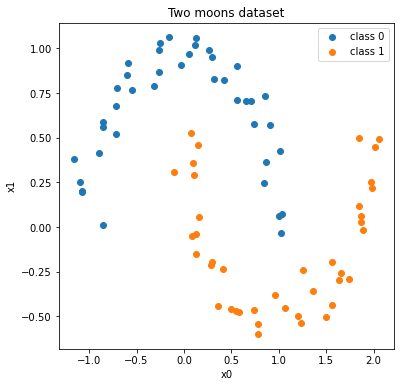

In [11]:
#Import and make dataset
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=80, noise=0.08, random_state=42)

plt.figure(figsize=(6,6))
for label in np.unique(y):
    pts = X[y == label]
    plt.scatter(pts[:, 0], pts[:, 1], label=f"class {label}")
plt.xlabel("x0")
plt.ylabel("x1")
plt.title("Two moons dataset")
plt.legend()
plt.show()

In [12]:
#split train/test

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [13]:
#for quantum kernel I will proceed to use previously defined one
#classical baseline
def classical_rbf_kernel(x1, x2, gamma=1.0):
    return np.exp(-gamma * np.linalg.norm(x1 - x2)**2)

def classical_kernel_matrix(A, B, gamma=1.0):
    K = np.zeros((len(A), len(B)))
    for i in range(len(A)):
        for j in range(len(B)):
            K[i,j] = classical_rbf_kernel(A[i], B[j], gamma=gamma)
    return K

#Training -- quantum
Kq_train = kernel_matrix(X_train, X_train)
Kq_test = kernel_matrix(X_test, X_train)

clf_q = SVC(kernel="precomputed")
clf_q.fit(Kq_train, y_train)
y_pred_q = clf_q.predict(Kq_test)

print("Quantum accuracy", accuracy_score(y_test, y_pred_q))

#Training -- classical
Kc_train = classical_kernel_matrix(X_train, X_train, gamma=1.0)
Kc_test = classical_kernel_matrix(X_test, X_train, gamma=1.0)

clf_c = SVC(kernel="precomputed")
clf_c.fit(Kc_train, y_train)
y_pred_c = clf_c.predict(Kc_test)

print("Classical accuracy:", accuracy_score(y_test, y_pred_c))

Quantum accuracy 0.55
Classical accuracy: 0.95


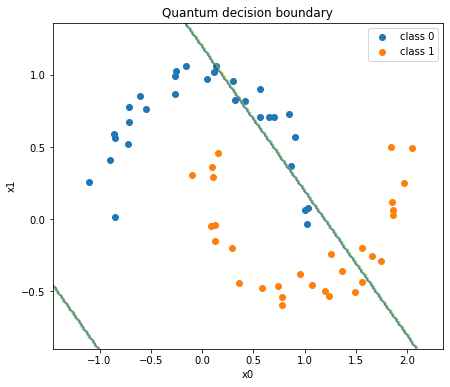

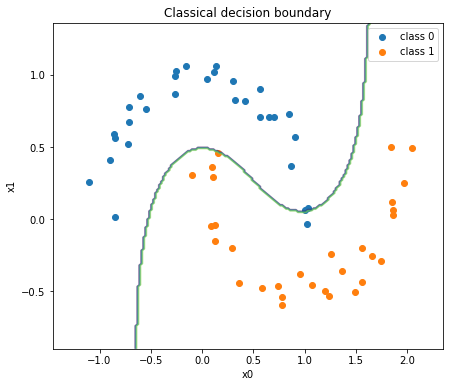

In [14]:
#Decision boundaries of two-moons set

#grid
x0_min, x0_max = X[:,0].min() - 0.3, X[:,0].max() + 0.3
x1_min, x1_max = X[:,1].min() - 0.3, X[:,1].max() + 0.3

xx, yy = np.meshgrid(
    np.linspace(x0_min, x0_max, 200),
    np.linspace(x1_min, x1_max, 200)
)
grid_points = np.c_[xx.ravel(), yy.ravel()]

#quantum
K_grid_q = kernel_matrix(grid_points, X_train)
Z_q = clf_q.predict(K_grid_q).reshape(xx.shape)

plt.figure(figsize=(7,6))
plt.contour(xx, yy, Z_q, alpha=0.35)
for label in np.unique(y_train):
    pts = X_train[y_train == label]
    plt.scatter(pts[:,0], pts[:,1], label=f"class {label}")
plt.title("Quantum decision boundary")
plt.xlabel("x0")
plt.ylabel("x1")
plt.legend()
plt.show()

#Classical
K_grid_c = classical_kernel_matrix(grid_points, X_train)
Z_q = clf_c.predict(K_grid_c).reshape(xx.shape)

plt.figure(figsize=(7,6))
plt.contour(xx, yy, Z_q, alpha=0.35)
for label in np.unique(y_train):
    pts = X_train[y_train == label]
    plt.scatter(pts[:, 0], pts[:, 1], label = f"class {label}")
plt.title("Classical decision boundary")
plt.xlabel("x0")
plt.ylabel("x1")
plt.legend()
plt.show()

NOTE: The minimal photonic kernel reproduces the quantum-kernel workflow and performs well on simple data, while being computationally lightweight. 
However, on more structured nonlinear datasets such as two moons, its shallow phase-interference feature map is not expressive enough to match the performance of more flexible kernels such as RBF, or the richer Havlíček-style map. Computed classification accuracies:

    Quantum accuracy 0.55
    Classical accuracy: 0.95